# Fake Reviews Dataset — Data Cleaning & EDA

**Dataset:** Salminen et al. (2022) "Amazon Fake Reviews Dataset"
Source: https://osf.io/tyue9/ (Kaggle mirror: "Fake Reviews Dataset")

**What this notebook does:**
1. Loads the raw file and prints its shape/columns (schema can vary slightly between the OSF and Kaggle mirrors, so this auto-detects common column names).
2. Cleans text (basic normalization — kept light on purpose; heavier NLP cleaning like stopword removal/lemmatization is done later in modeling, not here, since some signals like punctuation/case can be informative for detecting AI-generated text).
3. Handles missing values and duplicates.
4. Runs EDA: class balance, category distribution, rating distribution, review length distribution, verified-purchase cross-tab (if present).
5. Saves cleaned data + plots to an output folder.

**Common schema notes for this dataset:**
- Kaggle mirror columns are typically: `category`, `rating`, `label`, `text_` — label values: `'CG'` = Computer Generated (fake), `'OR'` = Original (real)
- OSF/paper version may include: `product_id`, `product_name`, `reviewer_name`, `verified_purchase`, `rating`, `text`, `label`

This notebook checks for both and normalizes to a common internal schema.

## Setup

Install requirements (uncomment if running in a fresh environment):

In [1]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Configuration

Set the paths for this run.

In [2]:
INPUT_PATH = "data/raw/fake_reviews_dataset.csv"   
OUTPUT_CSV = "data/processed/fake_reviews_cleaned.csv"  
EDA_DIR = "data/eda_outputs"                 


## 1. Load

Load the raw file and report its shape/columns.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded file: {INPUT_PATH}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

Loaded file: data/raw/fake_reviews_dataset.csv
Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']



In [4]:
df.head()


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## 2. Normalize Schema

Handles both known variants of this dataset (Kaggle mirror vs. OSF/paper version) and standardizes label values to human-readable `fake`/`real`.

In [5]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {}
    # text column
    for cand in ["text_", "text", "review_text", "review"]:
        if cand in df.columns:
            rename_map[cand] = "review_text"
            break
    # label column
    for cand in ["label", "class", "class_label"]:
        if cand in df.columns:
            rename_map[cand] = "label"
            break
    # rating
    for cand in ["rating", "rating value", "star_rating"]:
        if cand in df.columns:
            rename_map[cand] = "rating"
            break
    # category
    for cand in ["category", "product_category"]:
        if cand in df.columns:
            rename_map[cand] = "category"
            break
    # verified purchase (may not exist in Kaggle mirror)
    for cand in ["verified_purchase", "verified purchase", "verified"]:
        if cand in df.columns:
            rename_map[cand] = "verified_purchase"
            break

    df = df.rename(columns=rename_map)

    # Standardize label values to human-readable fake/real
    if "label" in df.columns:
        label_map = {
            "cg": "fake", "computer generated": "fake", "fake": "fake", "1": "fake", 1: "fake",
            "or": "real", "original": "real", "real": "real", "0": "real", 0: "real",
        }
        df["label_clean"] = (
            df["label"].astype(str).str.strip().str.lower().map(label_map)
        )
        unmapped = df["label_clean"].isna().sum()
        if unmapped:
            print(f"WARNING: {unmapped} rows had an unrecognized label value — inspect df['label'].unique()")

    return df


In [6]:
df = normalize_columns(df)
df.head()


,category,rating,label,review_text,label_clean
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",fake
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",fake
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,fake
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",fake
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,fake


## 3. Clean

Light text normalization, duplicate/missing-value handling, and a helper `review_word_count` column.

In [7]:
def basic_text_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    text = re.sub(r"http\S+|www\.\S+", "", text)  # strip URLs
    return text


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    n_before = len(df)

    if "review_text" in df.columns:
        df["review_text"] = df["review_text"].apply(basic_text_clean)
        df = df[df["review_text"].str.len() > 0]

    # Drop exact duplicate reviews
    if "review_text" in df.columns:
        df = df.drop_duplicates(subset=["review_text"])

    # Drop rows with no usable label
    if "label_clean" in df.columns:
        df = df.dropna(subset=["label_clean"])

    # Add helper column: review length in words
    if "review_text" in df.columns:
        df["review_word_count"] = df["review_text"].str.split().str.len()

    n_after = len(df)
    print(f"Rows before cleaning: {n_before}")
    print(f"Rows after cleaning:  {n_after}")
    print(f"Rows removed:         {n_before - n_after}\n")

    return df.reset_index(drop=True)


In [8]:
df = clean_data(df)
df.head()


Rows before cleaning: 40432
Rows after cleaning:  40405
Rows removed:         27



,category,rating,label,review_text,label_clean,review_word_count
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfort...",fake,12
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I'...",fake,16
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,fake,14
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",fake,17
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,fake,18


## 4. Exploratory Data Analysis

Class balance, category distribution, rating distribution, review length distribution, and verified-purchase cross-tab (if present). Plots are saved to `EDA_DIR` and also rendered inline below.

Class balance (fake vs real):
label_clean
real    20215
fake    20190
Name: count, dtype: int64 



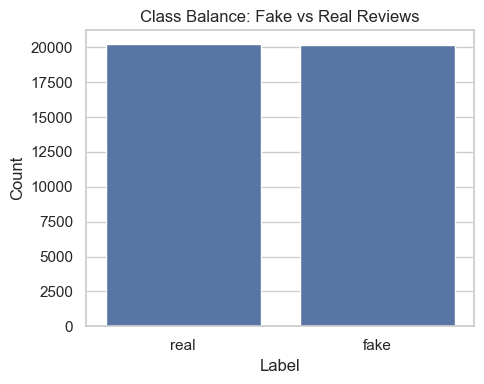

In [9]:
counts = df["label_clean"].value_counts()
print("Class balance (fake vs real):")
print(counts, "\n")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label_clean", order=counts.index)
plt.title("Class Balance: Fake vs Real Reviews")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "class_balance.png"), dpi=150)
plt.show()

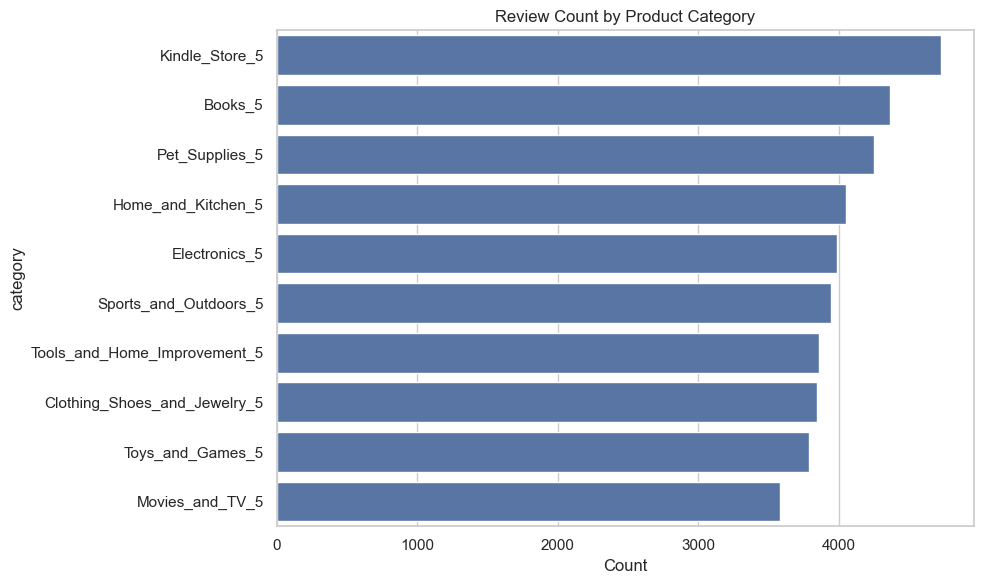

In [10]:
plt.figure(figsize=(10, 6))
top_cats = df["category"].value_counts().head(30)
sns.barplot(x=top_cats.values, y=top_cats.index)
plt.title("Review Count by Product Category")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "category_distribution.png"), dpi=150)
plt.show()

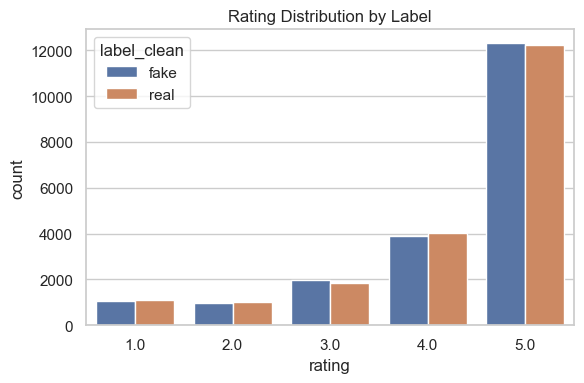

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="rating", hue="label_clean")
plt.title("Rating Distribution by Label")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "rating_by_label.png"), dpi=150)
plt.show()

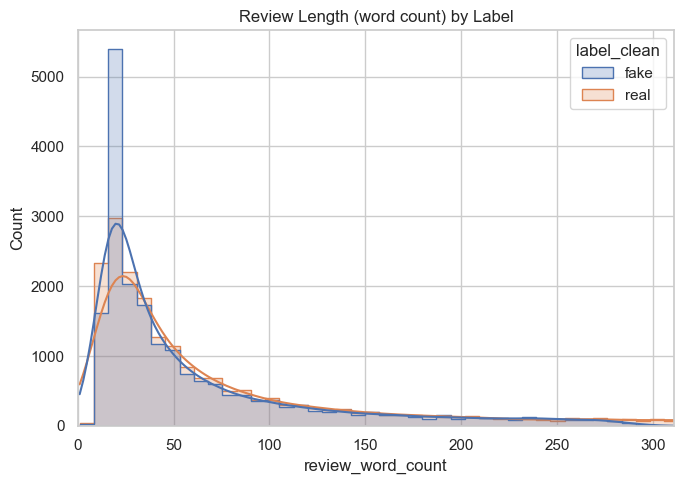

Review word count summary by label:
               count       mean        std  min   25%   50%   75%    max
label_clean                                                             
fake         20190.0  61.330362  61.823433  1.0  19.0  35.0  77.0  318.0
real         20215.0  73.641405  76.078243  5.0  23.0  42.0  93.0  373.0 



In [12]:
plt.figure(figsize=(7, 5))
sns.histplot(
    data=df, x="review_word_count", hue="label_clean",
    bins=50, kde=True, element="step"
)
plt.title("Review Length (word count) by Label")
plt.xlim(0, df["review_word_count"].quantile(0.99))  # trim extreme outliers for readability
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "review_length_by_label.png"), dpi=150)
plt.show()

print("Review word count summary by label:")
print(df.groupby("label_clean")["review_word_count"].describe(), "\n")

## 5. Save Cleaned Dataset

In [13]:
print(df['category'].nunique())
print(df['category'].unique())


10
['Home_and_Kitchen_5' 'Sports_and_Outdoors_5' 'Electronics_5'
 'Movies_and_TV_5' 'Tools_and_Home_Improvement_5' 'Pet_Supplies_5'
 'Kindle_Store_5' 'Books_5' 'Toys_and_Games_5'
 'Clothing_Shoes_and_Jewelry_5']


In [14]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Cleaned dataset saved to: {OUTPUT_CSV}")


Cleaned dataset saved to: data/processed/fake_reviews_cleaned.csv
